**CAPSTONE PROJECT** - **MODULE 6** - **CLASSIFICATION TATA STEEL MACHINE FAILURE PREDICTION**


Submitter - Sanket Vijay Tandulkar

**Objective** : Build a machine learning classification model that predicts whether a machine will fail based on operational parameters.

**Complete Project Roadmap** : Business Understanding, Dataset Understanding, Data Cleaning, EDA, Feature Engineering, Handling Imbalance, Model Building, Model Evaluation, Hyperparameter Tuning, Feature Importance, Final Business Insights.

**1. Business Problem Statement - TATA Steel wants to reduce unexpected machine breakdowns.**


Unexpected machine failures cause could be:

*   Production downtime
*   Financial losses
*   Maintenance costs
*   Reduced operational efficiency
*   Product quality issues

The goal is to build a predictive model that can:


1.   Predict machine failures early
2.   Help maintenance teams act proactively
3.   Reduce operational risk


**ML Problem Type** : Supervised Machine Learning Problem

**Classification Type** : Binary Classification, Multi-class Classification ( We will verify after loading dataset)




**2. Dataset Understanding**

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading provided Train.csv and Test.scv Dataset

# Train Dataset
train_df = pd.read_csv('https://raw.githubusercontent.com/Standulkar/ML-Classification---Tata-Steel-Machine-Failure-Prediction/refs/heads/main/Data/train.csv')

# Test Dataset
test_df = pd.read_csv('https://raw.githubusercontent.com/Standulkar/ML-Classification---Tata-Steel-Machine-Failure-Prediction/refs/heads/main/Data/test.csv')

**Initial inspections with datasets**

In [3]:
train_df.shape

(136429, 14)

In [4]:
test_df.shape

(90954, 13)

In [5]:
train_df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [6]:
test_df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0


In [7]:
train_df.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [8]:
test_df.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: f

In [10]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90954 entries, 0 to 90953
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       90954 non-null  int64  
 1   Product ID               90954 non-null  object 
 2   Type                     90954 non-null  object 
 3   Air temperature [K]      90954 non-null  float64
 4   Process temperature [K]  90954 non-null  float64
 5   Rotational speed [rpm]   90954 non-null  int64  
 6   Torque [Nm]              90954 non-null  float64
 7   Tool wear [min]          90954 non-null  int64  
 8   TWF                      90954 non-null  int64  
 9   HDF                      90954 non-null  int64  
 10  PWF                      90954 non-null  int64  
 11  OSF                      90954 non-null  int64  
 12  RNF                      90954 non-null  int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 9.0+ MB


In [11]:
train_df.describe()  # Statistical Summary

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000
mean,68214.000000,299.862776,309.941070,1520.331110,40.348643,104.408901,0.015744,0.001554,0.005160,0.002397,0.003958,0.002258
std,39383.804275,1.862247,1.385173,138.736632,8.502229,63.965040,0.124486,0.039389,0.071649,0.048899,0.062789,0.047461
min,0.000000,295.300000,305.800000,1181.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34107.000000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,68214.000000,300.000000,310.000000,1493.000000,40.400000,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,102321.000000,301.200000,310.900000,1580.000000,46.100000,159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,136428.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
test_df.describe() # Statistical summary

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
count,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.00000,90954.000000
mean,181905.500000,299.859493,309.939375,1520.528179,40.335191,104.293962,0.001473,0.005343,0.002353,0.00387,0.002309
std,26256.302529,1.857562,1.385296,139.970419,8.504683,63.871092,0.038355,0.072903,0.048449,0.06209,0.047995
min,136429.000000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,159167.250000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,181905.500000,300.000000,310.000000,1493.000000,40.500000,106.000000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,204643.750000,301.200000,310.900000,1579.000000,46.200000,158.000000,0.000000,0.000000,0.000000,0.00000,0.000000
max,227382.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.00000,1.000000


In [13]:
train_df.isnull().sum()   # Checking missing values

,0
id,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [14]:
test_df.isnull().sum()

,0
id,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
TWF,0
HDF,0


In [15]:
print("Train dataset Duplicates :", train_df.duplicated().sum())
print("Test dataset Duplicates :", test_df.duplicated().sum())

Train dataset Duplicates : 0
Test dataset Duplicates : 0


No null values

No Duplicate Values

**Dataset is Clean**



In [16]:
# Let's check for Target Column

train_df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


**Target Column - Machine failure**

In [17]:
# Seperating feature types - numerical columns and categorical columns

# Numerical columns
num_cols = train_df.select_dtypes(include=np.number).columns.tolist()

# Categorical columns
cat_cols = train_df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
['id', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Categorical Columns:
['Product ID', 'Type']


**We will check now Target distribution**

In [18]:
target = 'Machine failure'
train_df[target].value_counts()
train_df[target].value_counts(normalize=True) * 100

,proportion
Machine failure,
0,98.425555
1,1.574445


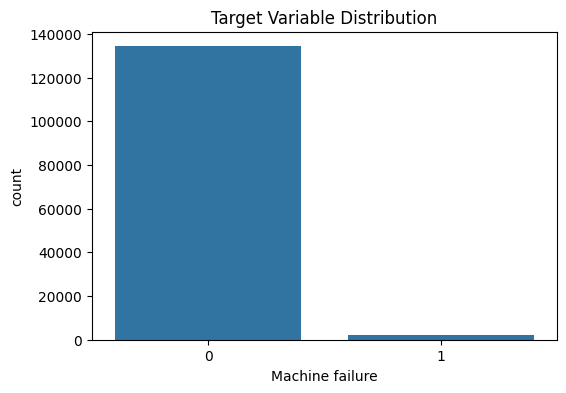

In [19]:
# Visualizing the distribution
plt.figure(figsize=(6,4))

sns.countplot(x=train_df[target])

plt.title("Target Variable Distribution")
plt.show()

**From this, we know that data is highly imbalanced**

This information matters because if we have directly trained the model, the model is useless because it never predicts failures.

example - Model predicts ALL rows as 0

Accuracy becomes 98.43%

Therefore, Accuracy is NOT the primary metric, we will focus on recall, F1  score, precision, ROC-AUC

Actual Failure = YES

Predicted Failure = NO

**We should prioritize Recall** - Because recall measures: Higher recall ⇒ fewer missed failures.

**Summary of observations till now**:

- Dataset is clean with no missing values.
- No duplicate records found.
- Dataset contains highly imbalanced target classes.
- Majority class (No Failure) represents ~98.43% of the data.
- Minority class (Failure) represents ~1.57% of the data.
- Accuracy alone will not be a reliable evaluation metric.
- Recall and F1-score will be prioritized during model evaluation.
- Imbalance handling techniques such as SMOTE or class weights may be required.

**We are good to go for EDA - Exploratory Data Analysis**

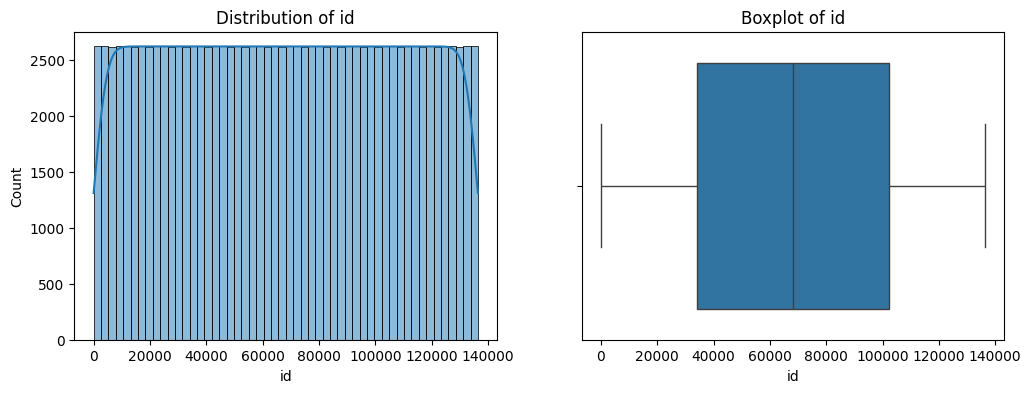

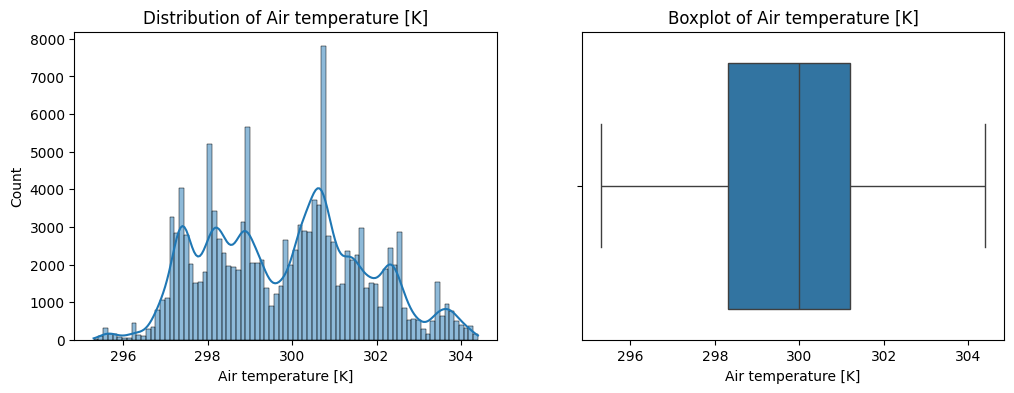

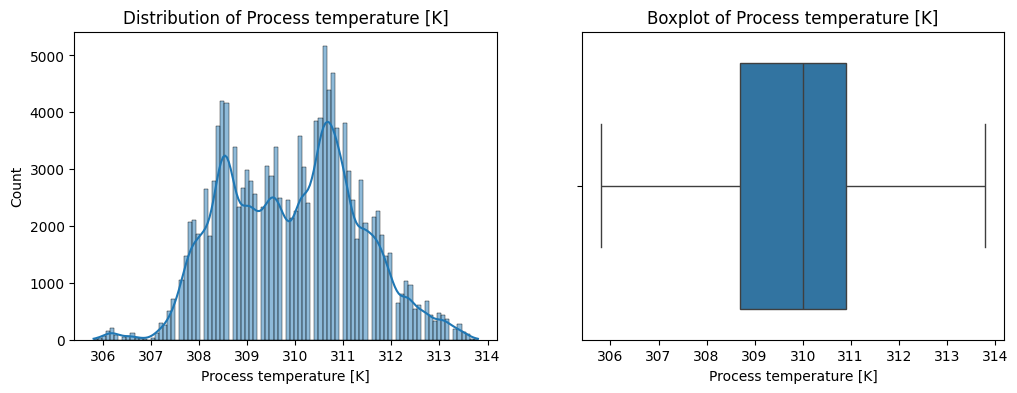

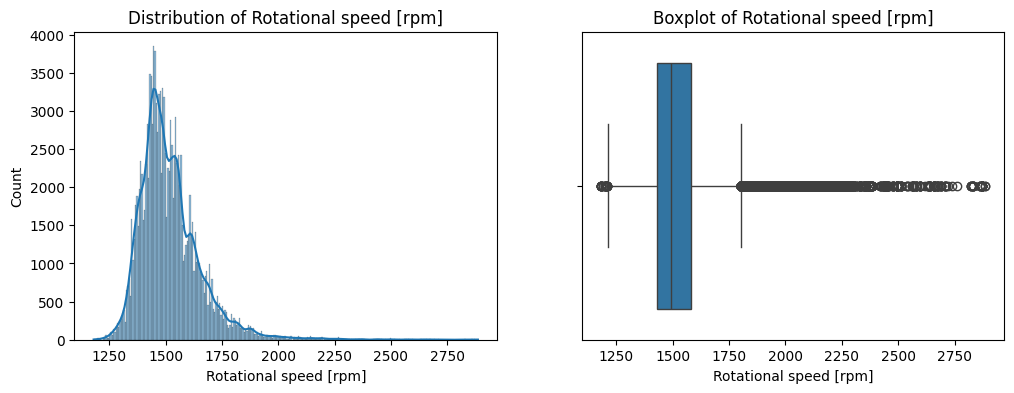

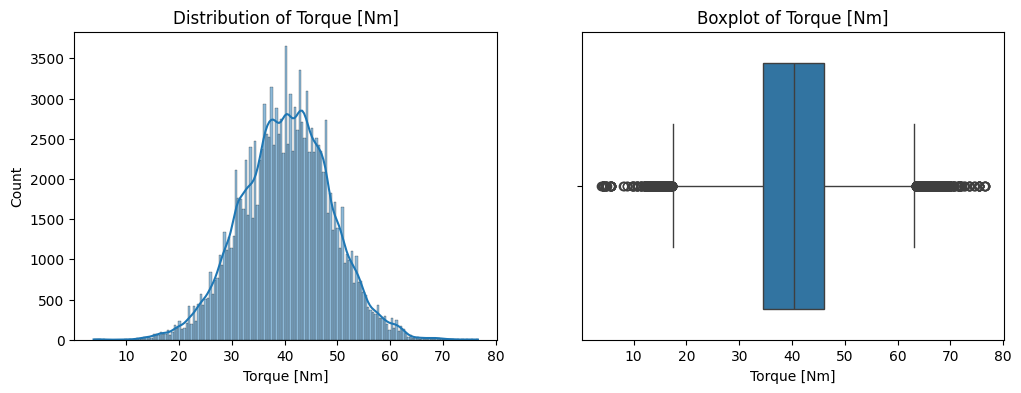

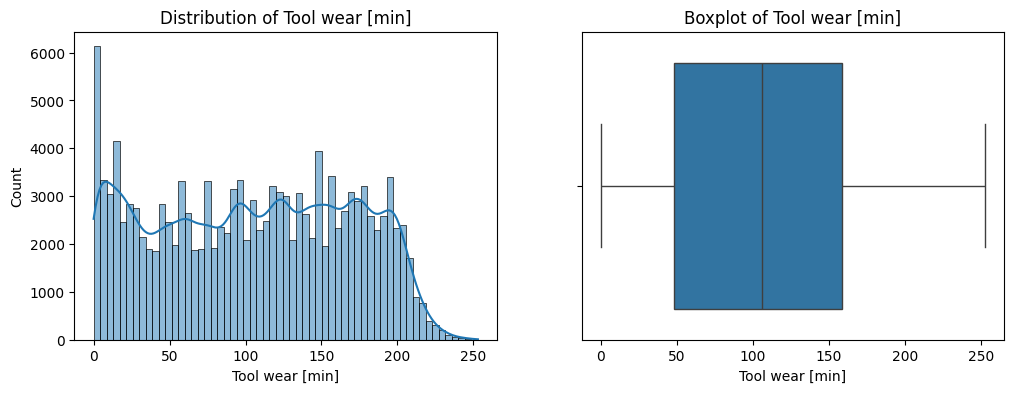

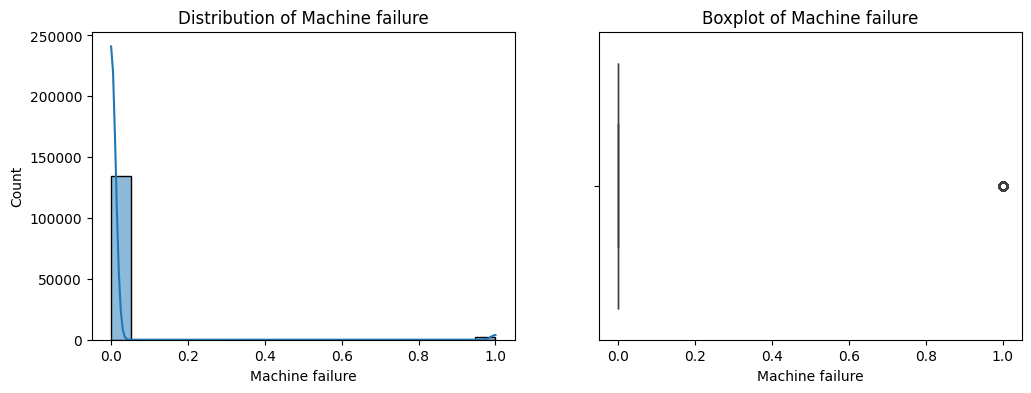

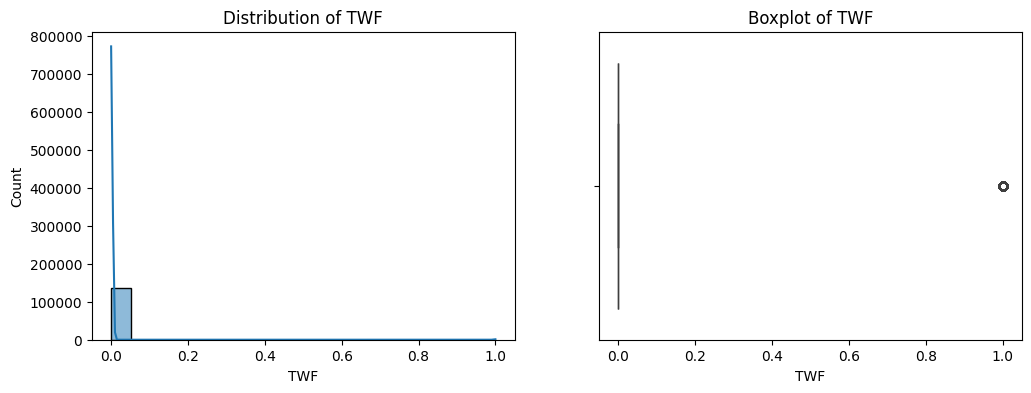

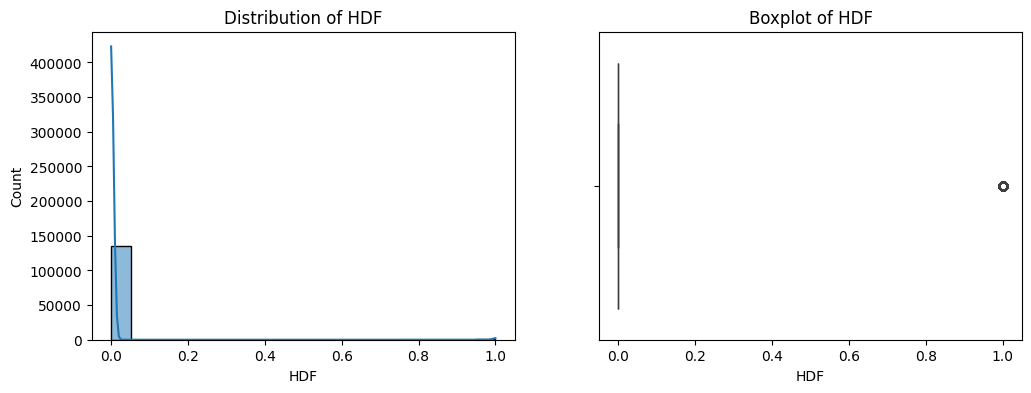

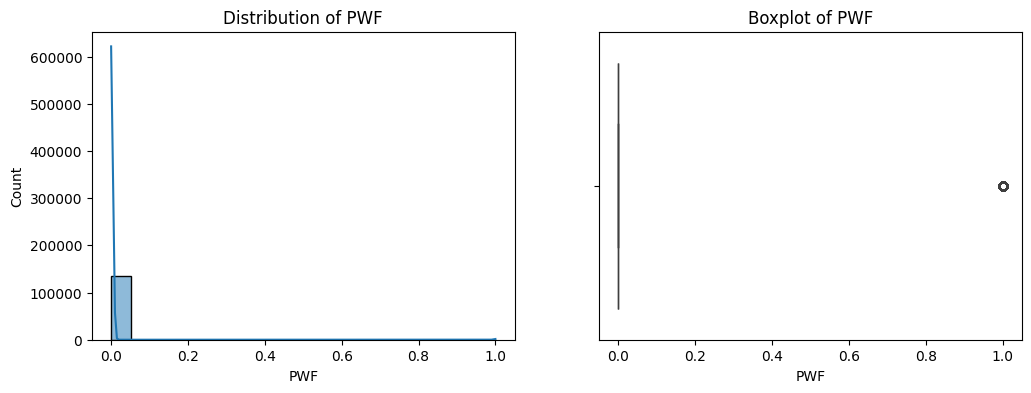

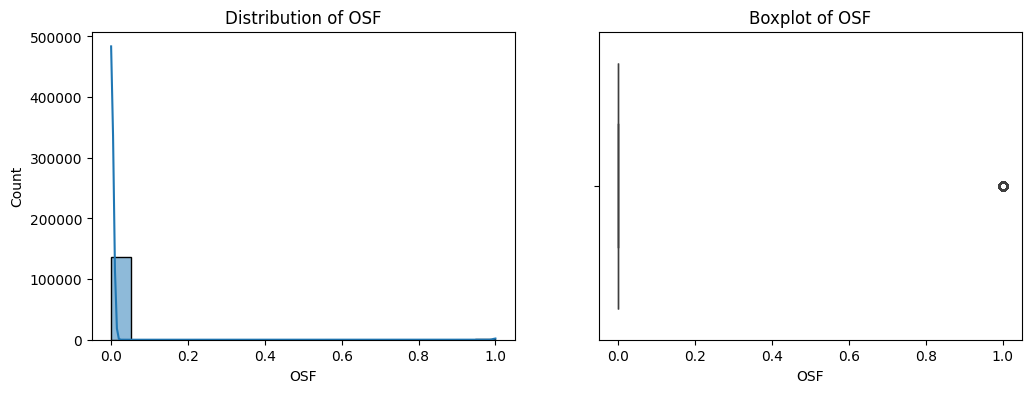

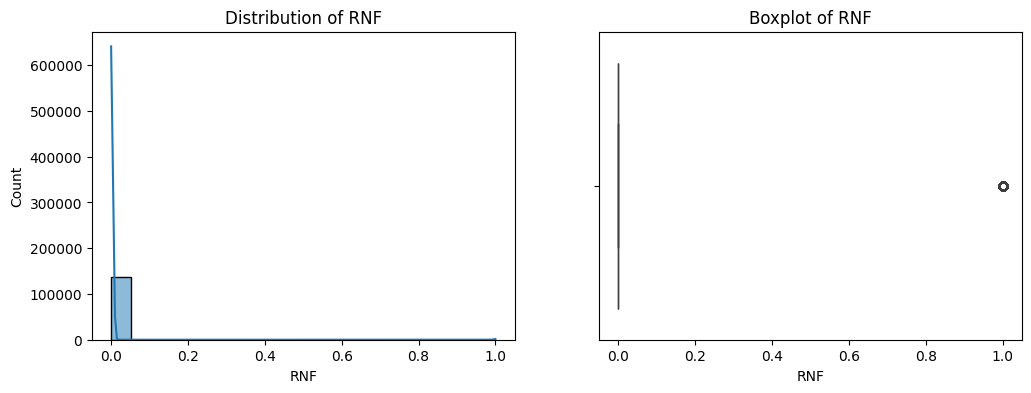

In [20]:
# Numerical feature distribution

for col in num_cols:

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.histplot(train_df[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.subplot(1,2,2)
    sns.boxplot(x=train_df[col])
    plt.title(f'Boxplot of {col}')

    plt.show()

Insights from above plotting:

- id behaves as an identifier and is unlikely to contribute to prediction.
- Air temperature and process temperature show stable distributions with limited outliers.
- Rotational speed is highly right-skewed with extreme values, which may represent abnormal machine behavior.
- Torque shows near-normal distribution with moderate outliers.
- Tool wear appears broadly distributed and may strongly influence failure prediction.
- Machine failure target is highly imbalanced (~98.43% non-failure).
- Failure indicator variables (TWF, HDF, PWF, OSF, RNF) may introduce target leakage and require further investigation.
- Outliers were retained because abnormal machine behavior may be meaningful for predictive maintenance.

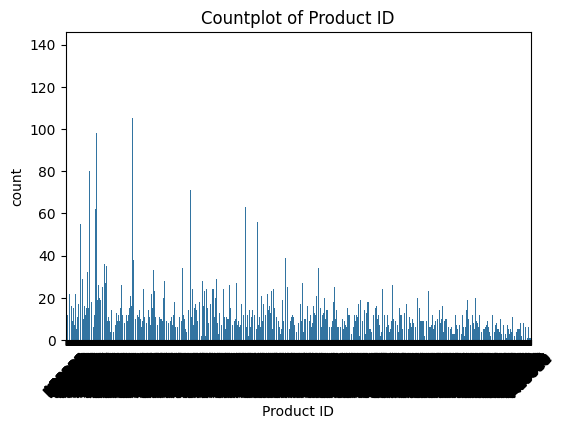

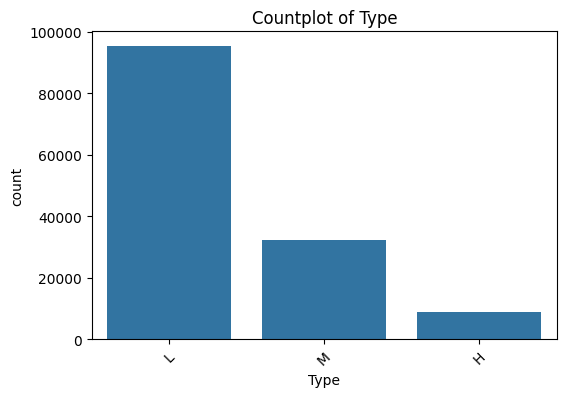

In [21]:
# Categorial feature analysis

for col in cat_cols:

    plt.figure(figsize=(6,4))
    sns.countplot(x=train_df[col])
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [22]:
train_df.columns.tolist()

['id',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [23]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

for col in failure_cols:
    print(f"\n{col}")
    print(pd.crosstab(train_df[col], train_df['Machine failure']))


TWF
Machine failure       0     1
TWF                          
0                134281  1936
1                     0   212

HDF
Machine failure       0     1
HDF                          
0                134275  1450
1                     6   698

PWF
Machine failure       0     1
PWF                          
0                134278  1824
1                     3   324

OSF
Machine failure       0     1
OSF                          
0                134277  1612
1                     4   536

RNF
Machine failure       0     1
RNF                          
0                133979  2142
1                   302     6


These 5 columns need to be removed:

Beacuse our goal is to Predict machine failure BEFORE it happens

In real production we will know: Temperature, RPM, Torque, Tool wear

But we will NOT know:

Tool Wear Failure, Heat Dissipation Failure, Overstrain Failure

Those are post-failure indicators.

Hence, using them for prediction model would make the model unrealistically perfect also called as leakage means we will get accuracy - 98% recall - 99%.

In [24]:
# Removing the cloumns / features

leakage_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

train_df.drop(columns=leakage_cols, inplace=True)
test_df.drop(columns=leakage_cols, inplace=True)

In [25]:
train_df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,0,L50096,L,300.6,309.6,1596,36.1,140,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0


In [26]:
test_df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,136429,L50896,L,302.3,311.5,1499,38.0,60
1,136430,L53866,L,301.7,311.0,1713,28.8,17
2,136431,L50498,L,301.3,310.4,1525,37.7,96
3,136432,M21232,M,300.1,309.6,1479,47.6,5
4,136433,M19751,M,303.4,312.3,1515,41.3,114


In [27]:
# Checking the Product ID column

train_df['Type'].value_counts()

,count
Type,
L,95354
M,32152
H,8923


In [28]:
train_df['Product_prefix'] = train_df['Product ID'].str[0]

pd.crosstab(
    train_df['Product_prefix'],
    train_df['Type']
)

Type,H,L,M
Product_prefix,,,
H,8923,0,0
L,0,95354,0
M,0,0,32152


So the Product ID column is also a redundant feature |  Product ID → directly contains Type

no new information

High cardinality noise

risk of overfitting

Hence dropping the column from both data set

In [29]:
train_df.drop(columns=['Product ID', 'Product_prefix'], inplace=True)

test_df.drop(columns=['Product ID'], inplace=True)

In [30]:
train_df.drop(columns=['id'], inplace=True)
test_df.drop(columns=['id'], inplace=True)

In [31]:
train_df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,L,300.6,309.6,1596,36.1,140,0
1,M,302.6,312.1,1759,29.1,200,0
2,L,299.3,308.5,1805,26.5,25,0
3,L,301.0,310.9,1524,44.3,197,0
4,M,298.0,309.0,1641,35.4,34,0


In [32]:
test_df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,L,302.3,311.5,1499,38.0,60
1,L,301.7,311.0,1713,28.8,17
2,L,301.3,310.4,1525,37.7,96
3,M,300.1,309.6,1479,47.6,5
4,M,303.4,312.3,1515,41.3,114


**Now our dataset is a proper predictive maintenance dataset**

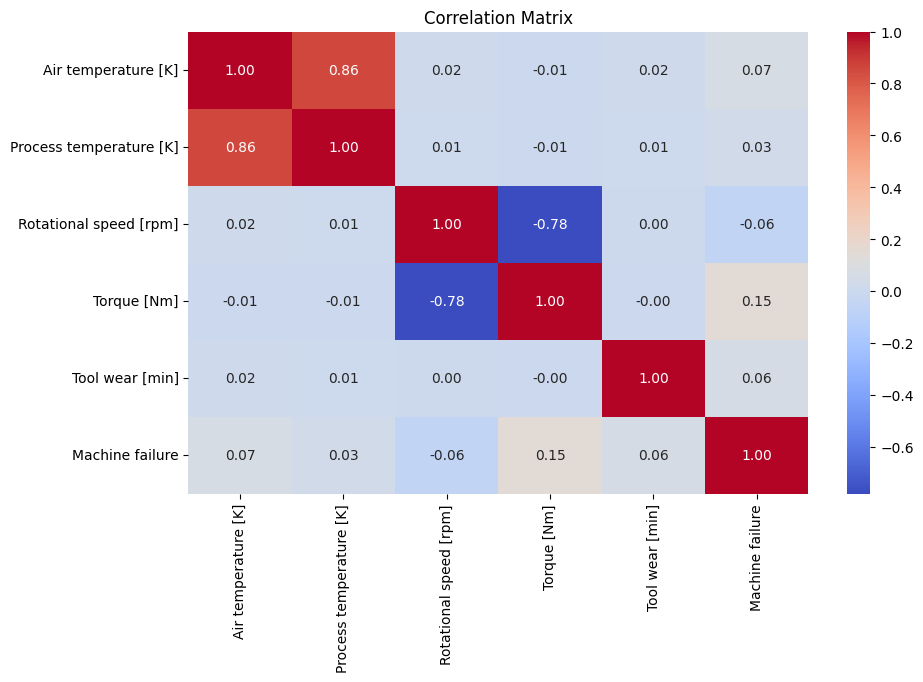

In [33]:
# Corelation heatmap to check the corelation between fetaures

plt.figure(figsize=(10,6))

corr = train_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

**Findings from Correlation Heatmap**

Air Temperature <-> Process Temperature  : High correlation
This suggests - When air temperature increases,
process temperature also increases.


Rotational Speed <-> Torque Correlation -0.78
High speed often means lower torque


Feature vs Target corelation

Lower correlation is not eqal to useless feature. Correlation only capture linear relationship, Machine failures are usually non colinear


**CONCLUSION** - **No severe multicollinearity problem**

Air temp ↔ Process temp is high. But manageable



**Feature Engineering**

In [34]:
#In machines: Absolute temperature matters less than thermal stress And thermal stress ≈ temperature difference.

train_df['temp_diff'] = (
    train_df['Process temperature [K]']
    - train_df['Air temperature [K]']
)

test_df['temp_diff'] = (
    test_df['Process temperature [K]']
    - test_df['Air temperature [K]']
)

In [35]:
# Since Type column / feature is categorigal L, M and H and not ordinal : we use here one hot encoding

train_df = pd.get_dummies(
    train_df,
    columns=['Type'],
    drop_first=True
)

test_df = pd.get_dummies(
    test_df,
    columns=['Type'],
    drop_first=True
)


# we used 'drop_first=True' to avoid dummy variable trap and multicolinearity

In [36]:
train_df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temp_diff,Type_L,Type_M
0,300.6,309.6,1596,36.1,140,0,9.0,True,False
1,302.6,312.1,1759,29.1,200,0,9.5,False,True
2,299.3,308.5,1805,26.5,25,0,9.2,True,False
3,301.0,310.9,1524,44.3,197,0,9.9,True,False
4,298.0,309.0,1641,35.4,34,0,11.0,False,True


In [37]:
# We can see Type_L and Type_M are boolean values converting them in 0 and 1 format

bool_cols = ['Type_L', 'Type_M']

train_df[bool_cols] = train_df[bool_cols].astype(int)
test_df[bool_cols] = test_df[bool_cols].astype(int)

In [38]:
train_df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temp_diff,Type_L,Type_M
0,300.6,309.6,1596,36.1,140,0,9.0,1,0
1,302.6,312.1,1759,29.1,200,0,9.5,0,1
2,299.3,308.5,1805,26.5,25,0,9.2,1,0
3,301.0,310.9,1524,44.3,197,0,9.9,1,0
4,298.0,309.0,1641,35.4,34,0,11.0,0,1


In [39]:
# Preapare features and target

X = train_df.drop('Machine failure', axis=1)
y = train_df['Machine failure']

print(X.shape)
print(y.shape)

(136429, 8)
(136429,)


We will separated the independent variables (X) and target variable (y) to prepare the dataset for machine learning model training. The target variable (Machine failure) is excluded from features to avoid data leakage.

In [40]:
# Train / Validation split as Test.csv dataset will remain untoched during model development !

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (109143, 8)
X_val: (27286, 8)


The dataset was split into training and validation sets to evaluate model performance on unseen data. stratify=y was used to preserve the original class imbalance distribution in both datasets.

In [41]:
# Perofimng SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

Since the dataset was highly imbalanced, SMOTE (Synthetic Minority Oversampling Technique) was applied only to the training set to generate synthetic minority samples and improve the model’s ability to detect machine failures.

In [42]:
# Verifying class Imbalance

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Machine failure
0    107425
1      1718
Name: count, dtype: int64

After SMOTE:
Machine failure
0    107425
1    107425
Name: count, dtype: int64


NEXT we will do **MODEL BUILDING** - Logistic Regression (Baseline)

Goal - Build multiple classification models and compare performance professionally.

Since this is a machine failure prediction problem with imbalance, our priority metric is: **Recall**

Because, missing a machine failure is more costly than raising a false alarm.

However, we will still evaluate **Recall, F1 Score, Precision, ROC curve, confusion matrix, classification report**


**We are building logistic regression model first as a baseline model to establish an initial benchmark for machine failure prediction performance.**

In [43]:
# importing required ML Libraries

# Libraries For Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Libraries For Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

Next, we will apply Feature scaling using StandardScaler to standardize numerical feature values. This helps distance-based and linear models such as Logistic Regression perform more effectively. Tree models do not need scaling but logistic get benefits from it.




In [44]:
# We will do sclaing here just for logistic regression

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_val_scaled = scaler.transform(X_val)

In [45]:
# We will train logistic regression model

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train_smote)

y_pred_lr = lr_model.predict(X_val_scaled)
y_prob_lr = lr_model.predict_proba(X_val_scaled)[:,1]

In [46]:
# Evaluting the model evaluation metrics as below

print("Logistic Regression Performance\n")

print("Accuracy :", accuracy_score(y_val, y_pred_lr))
print("Precision:", precision_score(y_val, y_pred_lr))
print("Recall   :", recall_score(y_val, y_pred_lr))
print("F1 Score :", f1_score(y_val, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_val, y_prob_lr))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_lr))

Logistic Regression Performance

Accuracy : 0.8283002272227515
Precision: 0.05556716106120744
Recall   : 0.6186046511627907
F1 Score : 0.10197431474027219
ROC AUC  : 0.7961520876197601

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.83      0.91     26856
           1       0.06      0.62      0.10       430

    accuracy                           0.83     27286
   macro avg       0.52      0.73      0.50     27286
weighted avg       0.98      0.83      0.89     27286



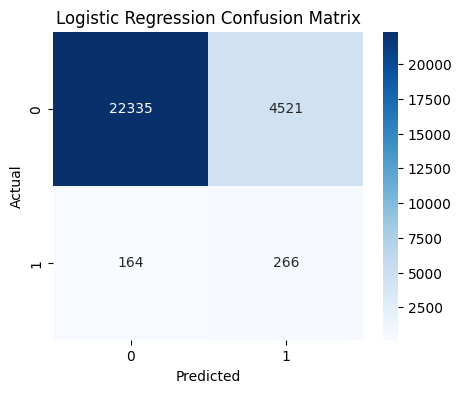

In [47]:
# Plotting the confusion matrix

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_val, y_pred_lr),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Logistic Regression Observations

Logistic Regression achieved moderate recall, successfully identifying a majority of machine failures. However, precision was low due to a high number of false positives, indicating that the model generated many unnecessary failure alerts. Since machine behavior is often non-linear, more advanced tree-based models may perform better.

**Model** - **Decision Tree**

In [48]:
# First we will train the model

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_smote, y_train_smote)

y_pred_dt = dt_model.predict(X_val)
y_prob_dt = dt_model.predict_proba(X_val)[:,1]

In [49]:
# Evaluating the model

print("Decision Tree Performance\n")

print("Accuracy :", accuracy_score(y_val, y_pred_dt))
print("Precision:", precision_score(y_val, y_pred_dt))
print("Recall   :", recall_score(y_val, y_pred_dt))
print("F1 Score :", f1_score(y_val, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_val, y_prob_dt))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_dt))

Decision Tree Performance

Accuracy : 0.9559847540863446
Precision: 0.151131221719457
Recall   : 0.3883720930232558
F1 Score : 0.21758957654723127
ROC AUC  : 0.6878674203850337

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     26856
           1       0.15      0.39      0.22       430

    accuracy                           0.96     27286
   macro avg       0.57      0.68      0.60     27286
weighted avg       0.98      0.96      0.97     27286



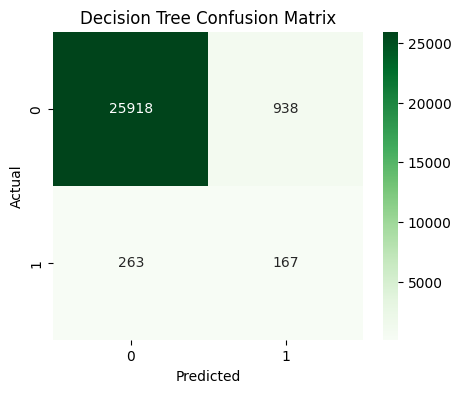

In [50]:
# plotting confusion matrix

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_val, y_pred_dt),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Decision Tree Observations**

Decision Tree is likely overfitting


Decision Tree improved overall accuracy and precision compared to Logistic Regression, while reducing false positive predictions. However, recall decreased significantly, meaning the model failed to detect a larger number of machine failures. Since minimizing missed failures is critical in predictive maintenance, Decision Tree may not be the optimal standalone model. So now we will train the Random forest model, evaluate and then compare the performance.

In [51]:
# Training the Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_val)
y_prob_rf = rf_model.predict_proba(X_val)[:,1]

In [52]:
# Evaluating the model

print("Random Forest Performance\n")

print("Accuracy :", accuracy_score(y_val, y_pred_rf))
print("Precision:", precision_score(y_val, y_pred_rf))
print("Recall   :", recall_score(y_val, y_pred_rf))
print("F1 Score :", f1_score(y_val, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_val, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_rf))

Random Forest Performance

Accuracy : 0.9736861394121528
Precision: 0.3048780487804878
Recall   : 0.5232558139534884
F1 Score : 0.3852739726027397
ROC AUC  : 0.9006241730227017

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     26856
           1       0.30      0.52      0.39       430

    accuracy                           0.97     27286
   macro avg       0.65      0.75      0.69     27286
weighted avg       0.98      0.97      0.98     27286



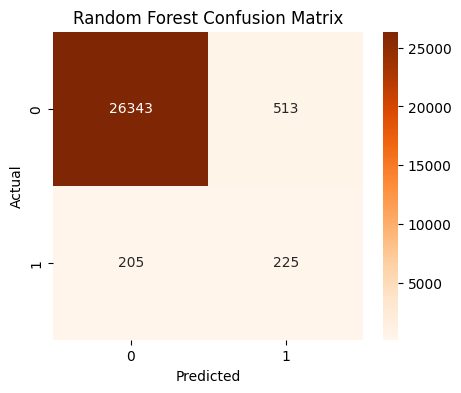

In [53]:
# Plotting the confusion matrix

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_val, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

After comparing with the previous two models we trained, Random Forest one is currently our best model.


Random Forest significantly improved predictive performance by increasing precision and F1-score while maintaining reasonable recall. The model reduced false positive predictions substantially and achieved strong ROC-AUC performance, making it a more balanced and practical choice for machine failure prediction.

In [54]:
# Training the XGBoost model

# But before training we have to clean the feature / column names because column name contains character '[]' XGBoost does not allow feature names containing this characters so we will rename those columns and then train the model.

X_train_smote.columns = (
    X_train_smote.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
    .str.replace(' ', '_')
)

X_val.columns = (
    X_val.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
    .str.replace(' ', '_')
)


In [55]:
# Verifying the coluns after change

print(X_train_smote.columns)

Index(['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm',
       'Torque_Nm', 'Tool_wear_min', 'temp_diff', 'Type_L', 'Type_M'],
      dtype='object')


In [56]:
# Now we can train the Xgboost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_val)
y_prob_xgb = xgb_model.predict_proba(X_val)[:,1]

In [57]:
# Evaluating the model

print("XGBoost Performance\n")

print("Accuracy :", accuracy_score(y_val, y_pred_xgb))
print("Precision:", precision_score(y_val, y_pred_xgb))
print("Recall   :", recall_score(y_val, y_pred_xgb))
print("F1 Score :", f1_score(y_val, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_val, y_prob_xgb))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_xgb))

XGBoost Performance

Accuracy : 0.9393095360258008
Precision: 0.1631868131868132
Recall   : 0.6906976744186046
F1 Score : 0.264
ROC AUC  : 0.9035100640106407

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.94      0.97     26856
           1       0.16      0.69      0.26       430

    accuracy                           0.94     27286
   macro avg       0.58      0.82      0.62     27286
weighted avg       0.98      0.94      0.96     27286



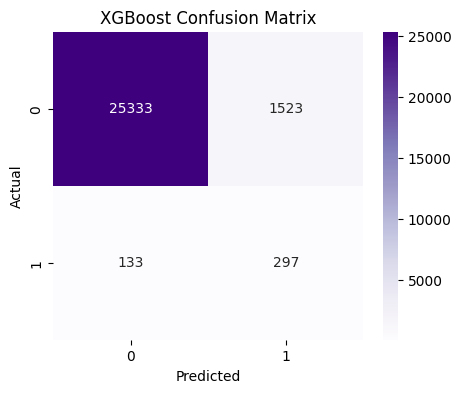

In [58]:
# Plotting the confusion matrix

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_val, y_pred_xgb),
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Now if we compare XGBoost with previous model, it looks like XGBoost is the strongest model among all.

XGBoost Observations

XGBoost achieved the highest recall among all models, successfully identifying the majority of machine failures while maintaining strong ROC-AUC performance. Although false positive predictions increased compared to Random Forest, the model minimized missed failures, making it highly suitable for predictive maintenance use cases where preventing unexpected breakdowns is critical.

So now, we have our best model - we will improve it's perfomance. For that we are gonna do Hyperparameter Tuning

We will Tune XGBoost (Best Model among all 4) and Machine failure prediction prioritizes recall and XGBoost already gave the best recall.

Here, Hyperparameter tuning will help to improve recall, refuce false negatives, improve ROC-AUC, and improve overall Generalization

We will use Method -- RandomizedsearchCV (it is fast, efficient)

In [59]:
# Importing required libraries

from sklearn.model_selection import RandomizedSearchCV

In [60]:
# Parameter Grid

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [61]:
# Initializing XGboost

xgb_tuned = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [62]:
# Next we will do, Random Search

random_search = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=param_grid,
    n_iter=10,
    scoring='recall',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='recall', verbose=1)

RandomizedSearchCV was used to automatically search for the best XGBoost hyperparameters by testing multiple parameter combinations using cross-validation, with recall selected as the optimization metric.

The output is showing like that because Google Colab automatically visualizes trained Scikit-Learn objects in an interactive UI format. It simply indicates that RandomizedSearchCV completed successfully and found the best XGBoost estimator.

In [63]:
print("Best Parameters:\n")
print(random_search.best_params_)

Best Parameters:

{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [64]:
# Best Model

best_xgb = random_search.best_estimator_

y_pred_best = best_xgb.predict(X_val)
y_prob_best = best_xgb.predict_proba(X_val)[:,1]

In [65]:
# Final Evaluation after Hyperparameter Tuning

print("Tuned XGBoost Performance\n")

print("Accuracy :", accuracy_score(y_val, y_pred_best))
print("Precision:", precision_score(y_val, y_pred_best))
print("Recall   :", recall_score(y_val, y_pred_best))
print("F1 Score :", f1_score(y_val, y_pred_best))
print("ROC AUC  :", roc_auc_score(y_val, y_prob_best))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_best))

Tuned XGBoost Performance

Accuracy : 0.9767646412079455
Precision: 0.35
Recall   : 0.5534883720930233
F1 Score : 0.42882882882882883
ROC AUC  : 0.89722382422013

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     26856
           1       0.35      0.55      0.43       430

    accuracy                           0.98     27286
   macro avg       0.67      0.77      0.71     27286
weighted avg       0.98      0.98      0.98     27286



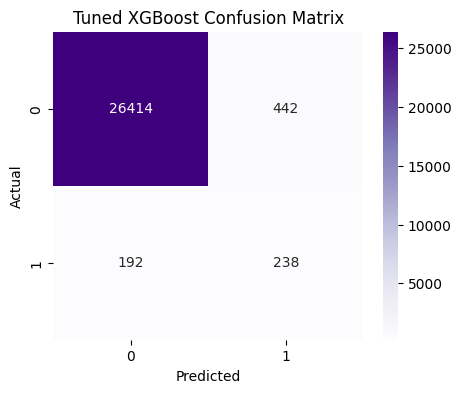

In [66]:
# Plotting the confusion matrix

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_val, y_pred_best),
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Hyperparameter tuning was performed using RandomizedSearchCV to identify the best XGBoost configuration. Recall was selected as the optimization metric to prioritize machine failure detection and reduce missed breakdowns.


Although the tuned XGBoost model achieved better precision and F1-score, the **untuned XGBoost model was selected as the final model because it achieved the highest recall, minimizing missed machine failures**. **In predictive maintenance scenarios, reducing false negatives is more critical than minimizing false positives, as unexpected machine breakdowns can result in significant operational and financial losses**.

**Next, we will see Feature Importance & Model Explainability**

Why do machines fail?

We’ll extract: most important features | failure drivers | business insights

In [67]:
# We will run this on untuned XGboost model : as explained above

feature_importance = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
2,Rotational_speed_rpm,0.284939
6,Type_L,0.197715
7,Type_M,0.120178
3,Torque_Nm,0.107571
4,Tool_wear_min,0.101765
5,temp_diff,0.086439
1,Process_temperature_K,0.068833
0,Air_temperature_K,0.032560


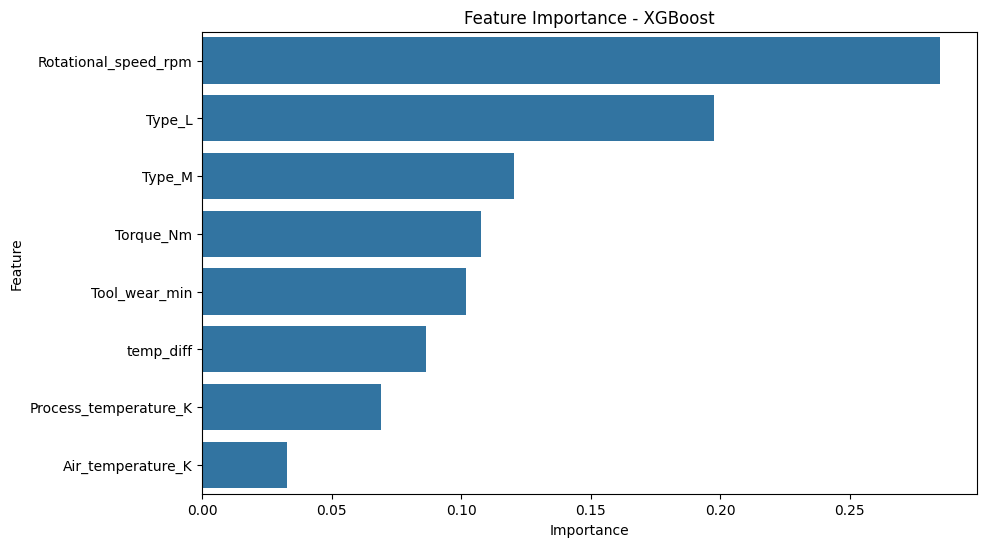

In [68]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - XGBoost")
plt.show()

**Business Insights**

- Rotational speed emerged as the most important predictor of machine failure, suggesting that abnormal RPM conditions strongly influence machine reliability.
- Machine type significantly affects failure likelihood, indicating different operational risk profiles across product categories.
- Torque and tool wear were important contributors, highlighting the impact of mechanical stress and equipment degradation.
- The engineered feature `temp_diff` proved useful, indicating thermal stress may contribute to failures.
- Predictive maintenance strategies focused on rotational speed, torque, and tool wear monitoring can help reduce unexpected downtime.

FINAL MODEL - Untuned XGBoost


Among all evaluated models, XGBoost was selected as the final model due to its superior recall performance and strong ROC-AUC score. Since machine failure prediction prioritizes minimizing missed failures, XGBoost was preferred despite producing more false positives. In predictive maintenance systems, preventing unexpected machine breakdowns is more critical than minimizing unnecessary inspections.

**FINAL CONCLUSION**

The objective of this project was to predict machine failures in Tata Steel manufacturing equipment using machine operational parameters. After performing data cleaning, exploratory data analysis, feature engineering, imbalance handling, and model experimentation, multiple classification models were evaluated.

Among all models, XGBoost emerged as the preferred model for machine failure prediction due to its superior recall performance and strong ROC-AUC score. Since predictive maintenance systems prioritize minimizing missed failures over false alarms, recall was considered the most important evaluation metric.

Feature importance analysis revealed that rotational speed, machine type, torque, and tool wear were the strongest contributors to machine failure prediction. These insights can help Tata Steel proactively identify risky operating conditions and reduce unexpected machine downtime.

The project demonstrates how machine learning can support predictive maintenance strategies, improve operational efficiency, and reduce maintenance-related costs in manufacturing environments.

**Azure Integration** (Future Scope)

If implemented in production, the model could be integrated with Azure cloud services to enable real-time machine failure prediction.

Machine Sensors ->  Azure IoT Hub -> Azure Data Lake / Blob Storage -> Azure ML Service -> XGBoost Prediction API -> Maintenance Dashboard / Alerts

1.   Azure IoT Hub can collect real-time sensor data from steel manufacturing machines.
2.   Azure Blob Storage or Data Lake can store historical machine telemetry.
3.   Azure Machine Learning Service can host the trained XGBoost model for prediction.
4. Predictions can trigger alerts through dashboards or automated maintenance workflows.

Although deployment was not implemented in this project, the trained XGBoost model can be integrated with Azure Machine Learning and IoT services to support real-time predictive maintenance in a manufacturing environment.








**What I Learned from the Project?** Through this project, I gained practical experience in building an end-to-end machine learning classification pipeline for predictive maintenance.

1.   Performing structured EDA to understand industrial sensor data.
2.   Identifying and removing target leakage features to avoid unrealistic model performance.
3.   Handling severe class imbalance using SMOTE.
4.   Building and evaluating multiple classification models including Logistic Regression, Decision Tree, Random Forest, and XGBoost.
5. Understanding tradeoffs between precision and recall in business-critical applications.
6. Performing feature engineering and model explainability using feature importance analysis.



**Business Value of the Model** - **Impact on Tata Steel Operations**

The model can provide significant business value by:

1.   Predicting machine failures before breakdown occurs.
2.   Reducing unexpected production downtime.
3.   Supporting preventive maintenance strategies.
4.   Improving equipment reliability and operational efficiency.
5.   Lowering maintenance and repair costs.

Since the selected XGBoost model prioritizes recall, it helps reduce missed failures, which is crucial in manufacturing environments.

**Future Improvements**

1.   Deploying the model using Azure Machine Learning API
2.   Integrating GenAI to generate automated maintenance recommendations.
3.   Building a monitoring system for model retraining and drift detection.

